In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
# DATA_PATH = Path("D:\Stress-level-classifier-main\Stress-level-classifier\data\processed\stress_level_dataset_v2_balanced.csv")

df = pd.read_csv('../data/processed/stress_level_dataset_v2_balanced.csv')

df.head()


,id,text,stress_level,source_type,source_name,source_url,source_record_id,original_label,label_mapping_rule,language,date_collected,collector,labeler,review_status,notes
0,balanced_00001,Is it possible to recover a career from a bad ...,Low,online_scraping_api,Stack Exchange API,https://academia.stackexchange.com/questions/1...,141861,academia:feeling confident,expanded_keyword_query_mapping_v2,English,2026-04-27,project_team,keyword_mapping_needs_manual_review,needs_review,Scraped online text; verify label manually bef...
1,balanced_00002,help me!!! any suggestion how to cure insomnia...,High,Mendeley Data public dataset,MentalDistress,https://data.mendeley.com/datasets/b42wr437hg/2,2360,Anxious,Anxious -> High: strong stress/anxiety expression,English,2026-04-27,project_team,source_label_mapping,needs_review,Depressed and Suicidal source classes excluded...
2,balanced_00003,Can I get funding for graduate study in the US...,Medium,online_scraping_api,Stack Exchange API,https://academia.stackexchange.com/questions/2...,206065,academia:concerned about grades,keyword_query_mapping_v1,English,2026-04-27,project_team,keyword_mapping_needs_manual_review,needs_review,Scraped online text; verify label manually bef...
3,balanced_00004,HIV or anxiety creating my symptoms? I had sha...,High,Mendeley Data public dataset,MentalDistress,https://data.mendeley.com/datasets/b42wr437hg/2,2736,Anxious,Anxious -> High: strong stress/anxiety expression,English,2026-04-27,project_team,source_label_mapping,needs_review,Depressed and Suicidal source classes excluded...
4,balanced_00005,Collaborator remade all the figures of our res...,Medium,online_scraping_api,Stack Exchange API,https://academia.stackexchange.com/questions/1...,196661,academia:time management problem,expanded_keyword_query_mapping_v2,English,2026-04-27,project_team,keyword_mapping_needs_manual_review,needs_review,Scraped online text; verify label manually bef...


In [6]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")


Dataset shape: (5523, 15)

Columns:
Index(['id', 'text', 'stress_level', 'source_type', 'source_name',
       'source_url', 'source_record_id', 'original_label',
       'label_mapping_rule', 'language', 'date_collected', 'collector',
       'labeler', 'review_status', 'notes'],
      dtype='object')

First 5 rows:


In [7]:
df["stress_level"].value_counts()

stress_level
Low       1841
High      1841
Medium    1841
Name: count, dtype: int64

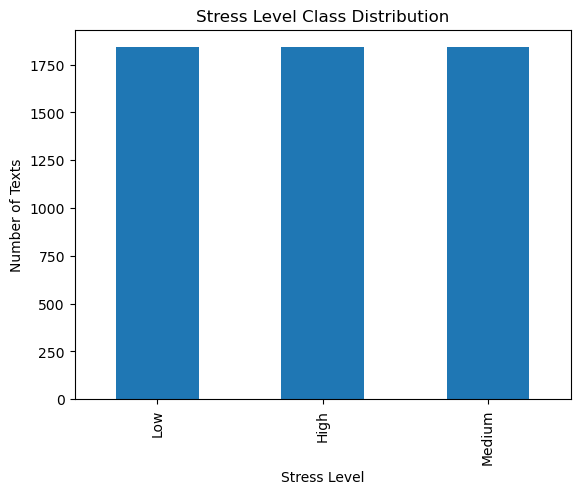

In [8]:
df["stress_level"].value_counts().plot(kind="bar")

plt.title("Stress Level Class Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Number of Texts")
plt.show()


In [9]:
df.isnull().sum()


id                    0
text                  0
stress_level          0
source_type           0
source_name           0
source_url            0
source_record_id      0
original_label        0
label_mapping_rule    0
language              0
date_collected        0
collector             0
labeler               0
review_status         0
notes                 0
dtype: int64

In [10]:
duplicate_count = df.duplicated(subset=["text"]).sum()

print("Number of duplicate text rows:", duplicate_count)


Number of duplicate text rows: 0


In [11]:
df["text_length"] = df["text"].astype(str).str.split().str.len()

df["text_length"].describe()

count    5523.000000
mean      142.671555
std       148.734688
min         4.000000
25%        35.000000
50%        80.000000
75%       200.000000
max      1167.000000
Name: text_length, dtype: float64

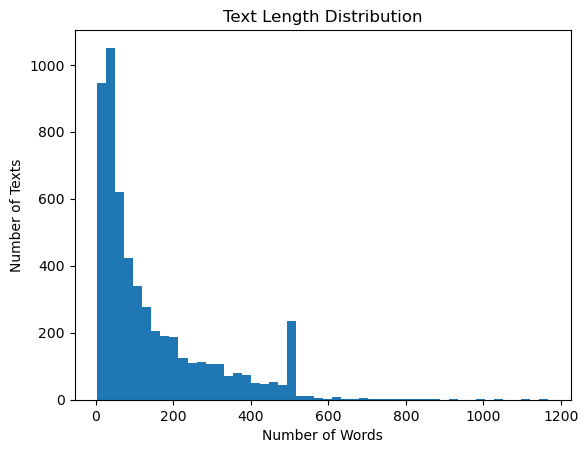

In [12]:
df["text_length"].plot(kind="hist", bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Texts")
plt.show()

In [13]:
model_df = df[["text", "stress_level"]].copy()

model_df.head()

,text,stress_level
0,Is it possible to recover a career from a bad ...,Low
1,help me!!! any suggestion how to cure insomnia...,High
2,Can I get funding for graduate study in the US...,Medium
3,HIV or anxiety creating my symptoms? I had sha...,High
4,Collaborator remade all the figures of our res...,Medium


In [14]:
X = model_df["text"]
y = model_df["stress_level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5523,)
y shape: (5523,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # keeps Low, Medium, and High balanced in both training and testing.
)

print("Training text count:", X_train.shape[0])
print("Testing text count:", X_test.shape[0])



Training text count: 4418
Testing text count: 1105


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=5000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4418, 5000)
Testing TF-IDF shape: (1105, 5000)


## Model 1 — Multinomial Naive Bayes

The first model we train is Multinomial Naive Bayes.

Naive Bayes is commonly used for text classification because it works well with word-frequency-based features such as TF-IDF.

It is simple, fast, and useful as a baseline model.

A baseline model gives us an initial performance result that we can compare with more advanced models later.

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Multinomial Naive Bayes Accuracy:", nb_accuracy)

Multinomial Naive Bayes Accuracy: 0.718552036199095


In [18]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

        High       0.83      0.80      0.81       368
         Low       0.64      0.71      0.67       368
      Medium       0.70      0.65      0.67       369

    accuracy                           0.72      1105
   macro avg       0.72      0.72      0.72      1105
weighted avg       0.72      0.72      0.72      1105



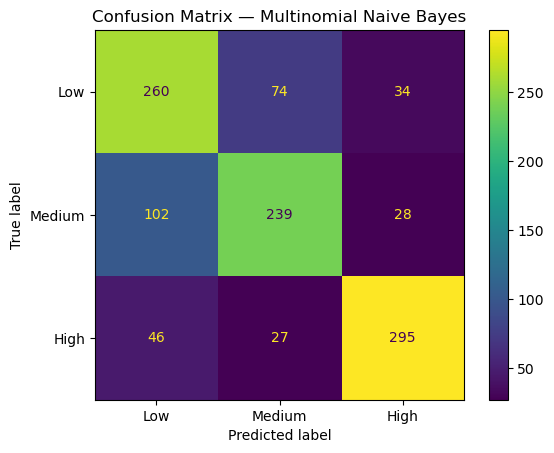

In [19]:
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, nb_predictions, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix — Multinomial Naive Bayes")
plt.show()

In [20]:
#saving results for comparison

In [21]:
from sklearn.metrics import precision_recall_fscore_support

model_results = []

nb_precision, nb_recall, nb_f1, _ = precision_recall_fscore_support(
    y_test,
    nb_predictions,
    average="macro",
    zero_division=0
)

model_results.append({
    "Model": "Multinomial Naive Bayes",
    "Accuracy": nb_accuracy,
    "Macro Precision": nb_precision,
    "Macro Recall": nb_recall,
    "Macro F1": nb_f1
})

model_results

[{'Model': 'Multinomial Naive Bayes',
  'Accuracy': 0.718552036199095,
  'Macro Precision': 0.7221755368814192,
  'Macro Recall': 0.718616216959271,
  'Macro F1': 0.7193617316071146}]

## Model 2 — Logistic Regression

The second model is Logistic Regression.

Logistic Regression is a linear classification algorithm. It learns weights for the TF-IDF words and phrases, then uses those weights to predict the stress level.

For example, words related to panic, pressure, or being overwhelmed may receive stronger weights for the High stress class.

We use Logistic Regression because it works well with sparse high-dimensional text data such as TF-IDF features.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

logreg_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=500,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    )
)

logreg_model.fit(X_train_tfidf, y_train)

logreg_predictions = logreg_model.predict(X_test_tfidf)

logreg_accuracy = accuracy_score(y_test, logreg_predictions)

print("Logistic Regression Accuracy:", logreg_accuracy)

Logistic Regression Accuracy: 0.7764705882352941


In [23]:
print(classification_report(y_test, logreg_predictions))

              precision    recall  f1-score   support

        High       0.89      0.83      0.86       368
         Low       0.71      0.75      0.73       368
      Medium       0.74      0.75      0.74       369

    accuracy                           0.78      1105
   macro avg       0.78      0.78      0.78      1105
weighted avg       0.78      0.78      0.78      1105



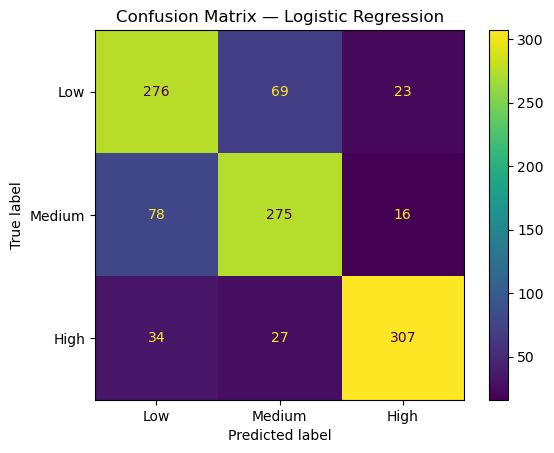

In [24]:
cm = confusion_matrix(y_test, logreg_predictions, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix — Logistic Regression")
plt.show()

In [25]:
logreg_precision, logreg_recall, logreg_f1, _ = precision_recall_fscore_support(
    y_test,
    logreg_predictions,
    average="macro",
    zero_division=0
)

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": logreg_accuracy,
    "Macro Precision": logreg_precision,
    "Macro Recall": logreg_recall,
    "Macro F1": logreg_f1
})

pd.DataFrame(model_results)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Multinomial Naive Bayes,0.718552,0.722176,0.718616,0.719362
1,Logistic Regression,0.776471,0.779954,0.776499,0.777782


## Model 3 — Linear Support Vector Machine

The third model is Linear Support Vector Machine, also called Linear SVM.

Linear SVM is a classification algorithm that tries to find the best separating boundary between classes.

It is commonly used for text classification because TF-IDF creates high-dimensional sparse features, and Linear SVM works well with this type of data.

In this project, Linear SVM will try to separate Low, Medium, and High stress texts based on their TF-IDF word and phrase patterns.

In [26]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.7574660633484163


In [27]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

        High       0.87      0.85      0.86       368
         Low       0.69      0.72      0.70       368
      Medium       0.72      0.70      0.71       369

    accuracy                           0.76      1105
   macro avg       0.76      0.76      0.76      1105
weighted avg       0.76      0.76      0.76      1105



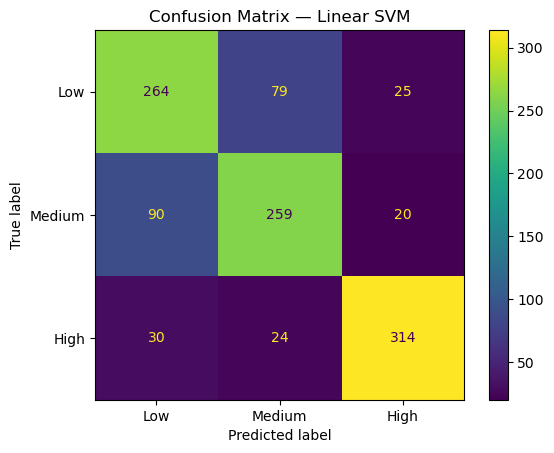

In [28]:
cm = confusion_matrix(y_test, svm_predictions, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix — Linear SVM")
plt.show()

In [29]:
svm_precision, svm_recall, svm_f1, _ = precision_recall_fscore_support(
    y_test,
    svm_predictions,
    average="macro",
    zero_division=0
)

model_results.append({
    "Model": "Linear SVM",
    "Accuracy": svm_accuracy,
    "Macro Precision": svm_precision,
    "Macro Recall": svm_recall,
    "Macro F1": svm_f1
})

pd.DataFrame(model_results)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Multinomial Naive Bayes,0.718552,0.722176,0.718616,0.719362
1,Logistic Regression,0.776471,0.779954,0.776499,0.777782
2,Linear SVM,0.757466,0.759207,0.757516,0.758190


## Model 4 — K-Nearest Neighbors

The fourth model is K-Nearest Neighbors, also called KNN.

KNN is different from the previous models because it does not learn weights during training. Instead, when a new text is given, it compares that text with the training texts and looks at the nearest examples.

The model then predicts the class based on the closest training examples.

We use cosine distance because our data is represented using TF-IDF vectors, and cosine distance is commonly used to compare text similarity.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    metric="cosine"
)

knn_model.fit(X_train_tfidf, y_train)

knn_predictions = knn_model.predict(X_test_tfidf)

knn_accuracy = accuracy_score(y_test, knn_predictions)

print("K-Nearest Neighbors Accuracy:", knn_accuracy)

K-Nearest Neighbors Accuracy: 0.7058823529411765


In [31]:
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

        High       0.83      0.79      0.81       368
         Low       0.62      0.70      0.66       368
      Medium       0.68      0.63      0.66       369

    accuracy                           0.71      1105
   macro avg       0.71      0.71      0.71      1105
weighted avg       0.71      0.71      0.71      1105



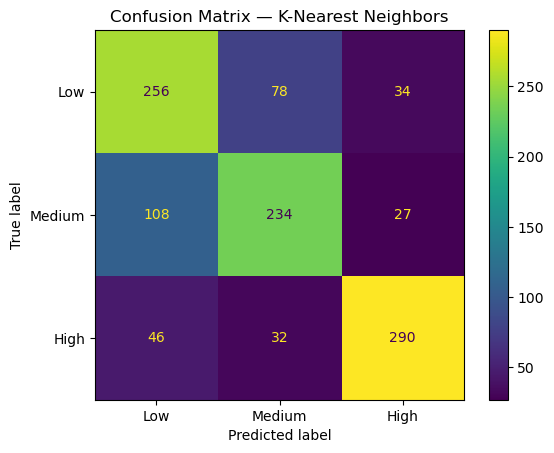

In [32]:
cm = confusion_matrix(y_test, knn_predictions, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix — K-Nearest Neighbors")
plt.show()

In [33]:
knn_precision, knn_recall, knn_f1, _ = precision_recall_fscore_support(
    y_test,
    knn_predictions,
    average="macro",
    zero_division=0
)

model_results.append({
    "Model": "K-Nearest Neighbors",
    "Accuracy": knn_accuracy,
    "Macro Precision": knn_precision,
    "Macro Recall": knn_recall,
    "Macro F1": knn_f1
})

pd.DataFrame(model_results)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Multinomial Naive Bayes,0.718552,0.722176,0.718616,0.719362
1,Logistic Regression,0.776471,0.779954,0.776499,0.777782
2,Linear SVM,0.757466,0.759207,0.757516,0.758190
3,K-Nearest Neighbors,0.705882,0.710278,0.705947,0.707052


## Model 5 — Decision Tree

The fifth model is Decision Tree.

A Decision Tree is a classification algorithm that makes decisions using a sequence of rules.

For example, the model may learn that certain TF-IDF features related to words such as stress, panic, tired, calm, or pressure help separate Low, Medium, and High stress texts.

Decision Trees are easy to understand because they follow rule-based logic, but they may not always perform as well as linear models on sparse text data.

In [34]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=60,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train_tfidf, y_train)

tree_predictions = tree_model.predict(X_test_tfidf)

tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.7067873303167421


In [35]:
print(classification_report(y_test, tree_predictions))

              precision    recall  f1-score   support

        High       0.84      0.77      0.81       368
         Low       0.70      0.55      0.62       368
      Medium       0.62      0.79      0.69       369

    accuracy                           0.71      1105
   macro avg       0.72      0.71      0.71      1105
weighted avg       0.72      0.71      0.71      1105



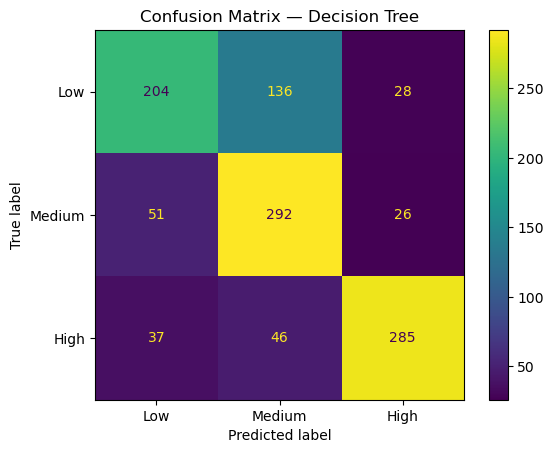

In [36]:
cm = confusion_matrix(y_test, tree_predictions, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix — Decision Tree")
plt.show()

In [37]:
tree_precision, tree_recall, tree_f1, _ = precision_recall_fscore_support(
    y_test,
    tree_predictions,
    average="macro",
    zero_division=0
)

model_results.append({
    "Model": "Decision Tree",
    "Accuracy": tree_accuracy,
    "Macro Precision": tree_precision,
    "Macro Recall": tree_recall,
    "Macro F1": tree_f1
})

pd.DataFrame(model_results)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Multinomial Naive Bayes,0.718552,0.722176,0.718616,0.719362
1,Logistic Regression,0.776471,0.779954,0.776499,0.777782
2,Linear SVM,0.757466,0.759207,0.757516,0.758190
3,K-Nearest Neighbors,0.705882,0.710278,0.705947,0.707052
4,Decision Tree,0.706787,0.718457,0.706711,0.705723


In [38]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Logistic Regression,0.776471,0.779954,0.776499,0.777782
2,Linear SVM,0.757466,0.759207,0.757516,0.758190
0,Multinomial Naive Bayes,0.718552,0.722176,0.718616,0.719362
3,K-Nearest Neighbors,0.705882,0.710278,0.705947,0.707052
4,Decision Tree,0.706787,0.718457,0.706711,0.705723


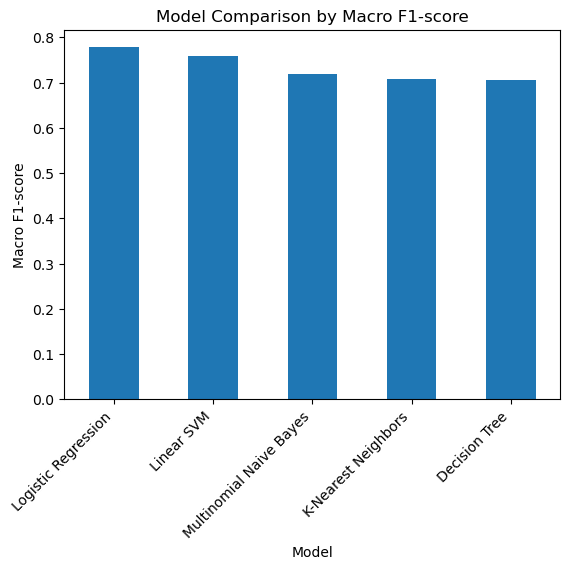

In [39]:
results_df.plot(
    x="Model",
    y="Macro F1",
    kind="bar",
    legend=False
)

plt.title("Model Comparison by Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.show()

In [40]:
best_model_row = results_df.iloc[0]

print("Best model:")
print(best_model_row)

Best model:
Model              Logistic Regression
Accuracy                      0.776471
Macro Precision               0.779954
Macro Recall                  0.776499
Macro F1                      0.777782
Name: 1, dtype: object


In [41]:
from pathlib import Path

reports_dir = Path("../reports/phase2")
reports_dir.mkdir(parents=True, exist_ok=True)

results_path = reports_dir / "model_comparison_metrics.csv"

results_df.to_csv(results_path, index=False)

print("Results saved to:", results_path)

Results saved to: ..\reports\phase2\model_comparison_metrics.csv


In [42]:
test_predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "naive_bayes_prediction": nb_predictions,
    "logistic_regression_prediction": logreg_predictions,
    "linear_svm_prediction": svm_predictions,
    "knn_prediction": knn_predictions,
    "decision_tree_prediction": tree_predictions
})

predictions_path = reports_dir / "test_set_predictions.csv"

test_predictions_df.to_csv(predictions_path, index=False)

print("Test predictions saved to:", predictions_path)

Test predictions saved to: ..\reports\phase2\test_set_predictions.csv


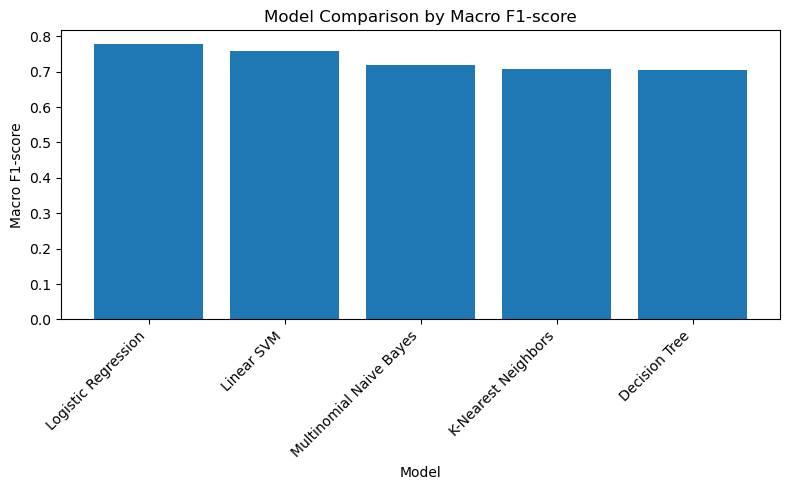

Figure saved to: ..\reports\figures\model_comparison_macro_f1.png


In [43]:
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["Macro F1"])

plt.title("Model Comparison by Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "model_comparison_macro_f1.png"
plt.savefig(figure_path, dpi=160)

plt.show()

print("Figure saved to:", figure_path)

In [44]:
import joblib
from sklearn.pipeline import Pipeline

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_objects = {
    "Multinomial Naive Bayes": nb_model,
    "Logistic Regression": logreg_model,
    "Linear SVM": svm_model,
    "K-Nearest Neighbors": knn_model,
    "Decision Tree": tree_model
}

best_model_name = best_model_row["Model"]
best_classifier = model_objects[best_model_name]

best_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", best_classifier)
])

model_path = models_dir / "best_stress_level_pipeline.joblib"

joblib.dump(best_pipeline, model_path)

print("Best model name:", best_model_name)
print("Best model saved to:", model_path)

Best model name: Logistic Regression
Best model saved to: ..\models\best_stress_level_pipeline.joblib


In [45]:
loaded_model = joblib.load(model_path)

sample_texts = [
    "I feel calm today and everything is going well.",
    "I am worried about my exams but I think I can manage.",
    "I feel overwhelmed and I cannot handle all this pressure."
]

for text in sample_texts:
    prediction = loaded_model.predict([text])[0]
    print("Text:", text)
    print("Predicted stress level:", prediction)
    print("-" * 50)

Text: I feel calm today and everything is going well.
Predicted stress level: High
--------------------------------------------------
Text: I am worried about my exams but I think I can manage.
Predicted stress level: Medium
--------------------------------------------------
Text: I feel overwhelmed and I cannot handle all this pressure.
Predicted stress level: High
--------------------------------------------------


In [46]:
if hasattr(loaded_model, "predict_proba"):
    probabilities = loaded_model.predict_proba(sample_texts)
    class_names = loaded_model.classes_

    for text, probs in zip(sample_texts, probabilities):
        print("Text:", text)
        for class_name, prob in zip(class_names, probs):
            print(class_name, ":", round(prob, 4))
        print("Predicted:", loaded_model.predict([text])[0])
        print("-" * 50)
else:
    print("This model does not support probability output.")

Text: I feel calm today and everything is going well.
High : 0.4655
Low : 0.4633
Medium : 0.0712
Predicted: High
--------------------------------------------------
Text: I am worried about my exams but I think I can manage.
High : 0.3898
Low : 0.2044
Medium : 0.4058
Predicted: Medium
--------------------------------------------------
Text: I feel overwhelmed and I cannot handle all this pressure.
High : 0.6593
Low : 0.2089
Medium : 0.1318
Predicted: High
--------------------------------------------------


In [47]:
sample_texts = [
    "I feel relaxed, calm, and able to handle my day without pressure or worry.",
    "I am a little worried about my exams, but I made a plan and I think I can manage it.",
    "I feel completely overwhelmed, anxious, and unable to handle all the pressure."
]

for text in sample_texts:
    prediction = loaded_model.predict([text])[0]
    print("Text:", text)
    print("Predicted stress level:", prediction)
    print("-" * 50)

Text: I feel relaxed, calm, and able to handle my day without pressure or worry.
Predicted stress level: Low
--------------------------------------------------
Text: I am a little worried about my exams, but I made a plan and I think I can manage it.
Predicted stress level: Medium
--------------------------------------------------
Text: I feel completely overwhelmed, anxious, and unable to handle all the pressure.
Predicted stress level: High
--------------------------------------------------
